In [2]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from cns.process.aggregation import group_samples, add_total_cn
from cns.display.plot import plot_lines, fig_lines, fig_dots,  fig_dots, plot_dots
from cns.data_utils import  main_load_data, get_cns_for_type, load_samples_out, load_merged_samples, load_all_samples, load_COSMIC, save_cns_fig
from cns.utils.conversions import segs_to_df, calc_mid

plt.rcParams.update({'font.size': 12})

In [4]:
tcga_samples = load_samples_out("TCGA_hg19_samples.tsv")
len(tcga_samples[tcga_samples["type"] == 'LUAD']) 

472

In [5]:
samples_df, cns_df = main_load_data("1MB")
datasets = samples_df["source"].unique()

In [6]:
luad_dict = { k : get_cns_for_type(cns_df, samples_df.query(f"source == '{k}'"), "LUAD") for k in datasets }
lusc_dict = { k : get_cns_for_type(cns_df, samples_df.query(f"source == '{k}'"), "LUSC") for k in datasets }
means_single = [add_total_cn(group_samples(dataset)) for dataset in [v for k, v in luad_dict.items()] + [v for k, v in lusc_dict.items()]]
luad_all = pd.concat([v for k, v in luad_dict.items()])
lusc_all = pd.concat([v for k, v in lusc_dict.items()])
means_all = [add_total_cn(group_samples(dataset)) for dataset in [luad_all, lusc_all]]

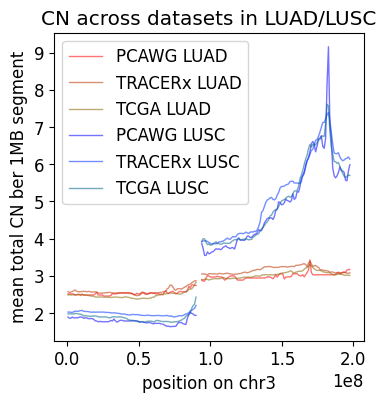

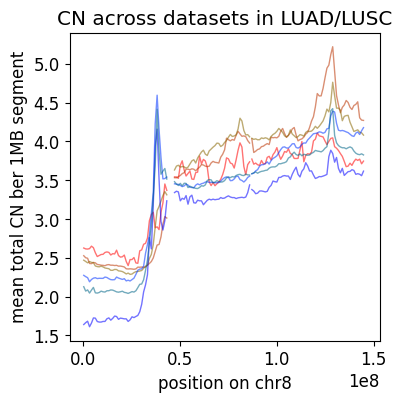

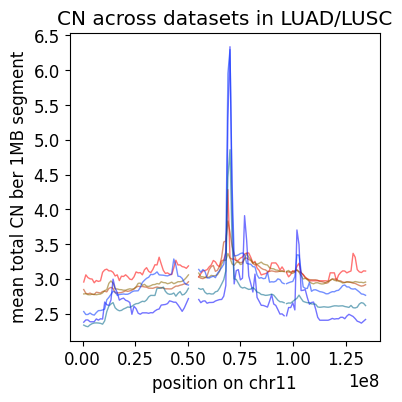

In [7]:
labels = ["PCAWG LUAD", "TRACERx LUAD", "TCGA LUAD", "PCAWG LUSC", "TRACERx LUSC", "TCGA LUSC"]
colors = ["#FF0000", "#BB3300", "#886600", "#0000FF", "#0033FF", "#006688"]
chroms = ["chr3", "chr8", "chr11"]
for chrom in chroms:
	fig, ax = fig_lines(means_single, labels, column="total_cn", color=colors, chrom=chrom)
	ax.set_ylabel("mean total CN ber 1MB segment")
	ax.set_title("CN across datasets in LUAD/LUSC")
	if chrom == "chr3":
		ax.legend(loc='upper left')
	else:
		# disable legend
		ax.legend().set_visible(False)
	save_cns_fig(f"fig_LUAD_LUSC_single_{chrom}")

In [8]:
# pearson correlation of means_single[0]["total_cn"] and means_single[1]["total_cn"]
sources = ["PCAWG", "TRACERx", "TCGA"]
print("Correlations on 1 Mb segments between datasets")
for ctype in ["LUAD", "LUSC"]:
	offset = 0 if ctype == "LUAD" else 3
	for i in range(3):
		for j in range(i+1, 3):
			corr = means_single[i + offset]["total_cn"].corr(means_single[j + offset]["total_cn"], method='pearson')
			print(ctype, sources[i], 'vs', sources[j], corr)

Correlations on 1 Mb segments between datasets
LUAD PCAWG vs TRACERx 0.7604749273921394
LUAD PCAWG vs TCGA 0.8287567740149921
LUAD TRACERx vs TCGA 0.8112712858283945
LUSC PCAWG vs TRACERx 0.8851163951724362
LUSC PCAWG vs TCGA 0.9656743086519447
LUSC TRACERx vs TCGA 0.8926420527143554


In [9]:
_, cosmic_df = main_load_data("COSMIC")
cosmic_group = group_samples(cosmic_df)
cosmic_genes = segs_to_df(load_COSMIC())
cosmic_genes.head()

,chrom,start,end,name
0,chr1,2160133,2241558,SKI
1,chr1,2487077,2496821,TNFRSF14
2,chr1,2985731,3355185,PRDM16
3,chr1,6241328,6269449,RPL22
4,chr1,6845383,7829766,CAMTA1


In [10]:
cosmic_lusc_group = add_total_cn(group_samples(get_cns_for_type(cosmic_df, samples_df, "LUSC")))
cosmic_lusc_group = cosmic_lusc_group.merge(cosmic_genes, on=["chrom", "start", "end", "name"])
cosmic_luad_group = add_total_cn(group_samples(get_cns_for_type(cosmic_df, samples_df, "LUAD")))
cosmic_luad_group = cosmic_luad_group.merge(cosmic_genes, on=["chrom", "start", "end", "name"])

In [11]:
# Plot the top attributions
cosmic_lusc_group.sort_values("total_cn", ascending=False).head()

,chrom,start,end,name,major_cn,minor_cn,total_cn
482,chr3,181429713,181432221,SOX2,5.756269,1.799398,7.555667
481,chr3,178865901,178957881,PIK3CA,5.118355,1.791374,6.909729
480,chr3,176737142,176915261,TBL1XR1,4.952859,1.793380,6.746239
483,chr3,185000728,185206885,MAP3K13,4.807422,1.726179,6.533601
484,chr3,185361526,185542844,IGF2BP2,4.726179,1.716148,6.442327


In [12]:
# Plot the neighbours of SOX2
cosmic_lusc_group.query("chrom == 'chr3'").query("start > 175000000").head()

,chrom,start,end,name,major_cn,minor_cn,total_cn
480,chr3,176737142,176915261,TBL1XR1,4.952859,1.793380,6.746239
481,chr3,178865901,178957881,PIK3CA,5.118355,1.791374,6.909729
482,chr3,181429713,181432221,SOX2,5.756269,1.799398,7.555667
483,chr3,185000728,185206885,MAP3K13,4.807422,1.726179,6.533601
484,chr3,185361526,185542844,IGF2BP2,4.726179,1.716148,6.442327


TBL1XR1 176826201 6.746238716148445
PIK3CA 178911891 6.9097291875626885
SOX2 181430967 7.555667001003009
EIF4A2 186504341 6.16148445336008
MUC4 195506391 5.861584754262788


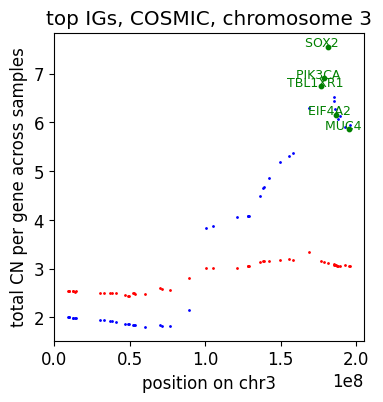

In [13]:
fig, ax = fig_dots(cosmic_lusc_group, chrom="chr3", column="total_cn")
plot_dots(ax, cosmic_luad_group, chrom="chr3", column="total_cn", color="red")
genes = ['EIF4A2', 'SOX2', 'TBL1XR1', 'PIK3CA', "MUC4"]

positions = {
    'EIF4A2': (0, 0),
    'SOX2': (0, 0),
    'TBL1XR1': (0, 0),
    'PIK3CA': (0, 0),
    "MUC4": (0, 0)
}

for i, row in cosmic_lusc_group.iterrows():
    if row['name'] in genes:
        mid = calc_mid(row)
        plt.scatter(mid, row['total_cn'], color='green', s=10)
        print(row['name'], mid, row['total_cn'])
        text = f"{row['name']}"
        x, y = positions[row['name']]
        plt.text(mid + x * 10**8, row['total_cn'] + y, text + "   ", color="green", size=9, ha='center')


ax.set_ylabel("total CN per gene across samples")
plt.title("top IGs, COSMIC, chromosome 3")
save_cns_fig(f"fig_COSMIC_dots_IG_att_chr3")

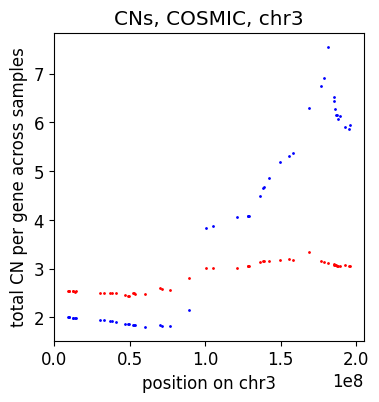

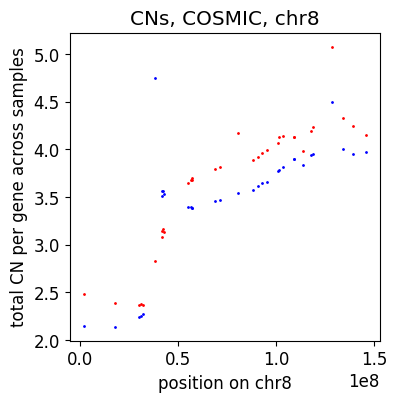

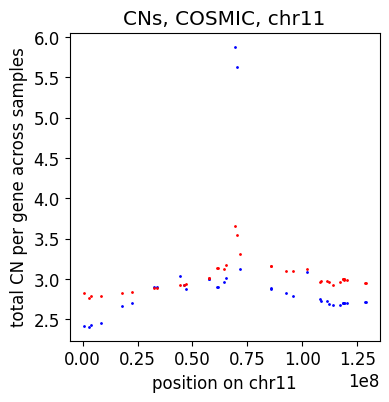

In [14]:
for chrom in chroms:
    fig, ax = fig_dots(cosmic_lusc_group, chrom=chrom, column="total_cn")
    plot_dots(ax, cosmic_luad_group, chrom=chrom, column="total_cn", color="red")

    ax.set_ylabel("total CN per gene across samples")
    plt.title(f"CNs, COSMIC, {chrom}")
    save_cns_fig(f"fig_COSMIC_IG_att_{chrom}")

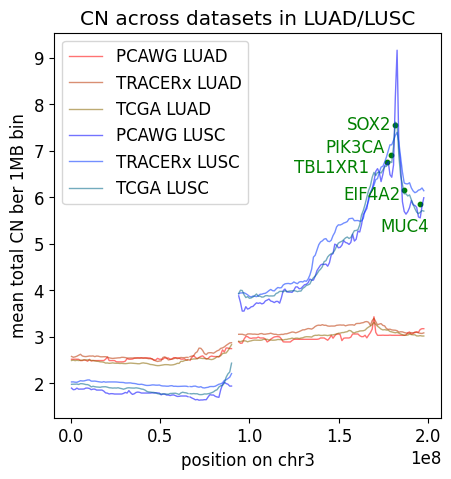

In [15]:
labels = ["PCAWG LUAD", "TRACERx LUAD", "TCGA LUAD", "PCAWG LUSC", "TRACERx LUSC", "TCGA LUSC"]
fig, ax = fig_lines(means_single, labels, column="total_cn", color=["#FF0000", "#BB3300", "#886600", "#0000FF", "#0033FF", "#006688"],  chrom="chr3")
ax.set_ylabel("mean total CN ber 1MB bin")
ax.set_title("CN across datasets in LUAD/LUSC")
ax.legend(loc='upper left')
fig.set_size_inches(5, 5) 

offsets = {
    'EIF4A2': (-.2, -.1),
    'SOX2': (-.2, 0),
    'TBL1XR1': (-1, -.1),
    'PIK3CA': (-.3, .15),
    "MUC4": (.5, -.5)
}

for i, row in cosmic_lusc_group.iterrows():
    if row['name'] in ['EIF4A2', 'SOX2', 'TBL1XR1', 'PIK3CA', "MUC4"]:
        mid = calc_mid(row)
        plt.scatter(mid, row['total_cn'], color='green', s=10)
        name = row['name']
        x, y = offsets[name]
        plt.text(mid + x*10**7, row['total_cn'] + y, name, color="green", size=12, ha='right', va='center')

save_cns_fig(f"fig_COSMIC_lines_IG_att_chr3")